# Milestone 3: Baseline Evaluation for Behavior-Signal Contrastive Learning on OpenOneRec

**CS 209B Project — Group 14**

Team members:
- Ji Zhang (jizhang@g.harvard.edu)
- Mengchu Yue (mengchuyue@fas.harvard.edu)
- Xiaoyu Yang (xiaoyu_yang1@g.harvard.edu)

---

## 1. Introduction & Problem Statement

### 1.1 Background: Traditional vs Generative Recommendation

Most recommendation systems work by **scoring and ranking**: given a user and a pool of candidate items, the system scores each (user, item) pair and returns the top-K items. This is how Netflix, YouTube, and most platforms operate — there is always a fixed catalog of items to choose from.

**OneRec** (Kuaishou, 2025) takes a fundamentally different approach: it is a **generative recommender** built on a large language model (LLM). Instead of scoring existing items, it *generates* the next items a user is likely to engage with — similar to how ChatGPT generates the next word in a sentence. The key insight is that items can be treated like "words" in a vocabulary if we give each item a compact token representation.

### 1.2 How Items Become Tokens: Semantic IDs

In a text LLM, each word maps to a token ID (e.g., "hello" → token 1234). OneRec does the same for items: each video is mapped to a **Semantic ID (SID)** — a sequence of 3 tokens:

```
Video #2360735  →  <s_a_4922><s_b_2117><s_c_4310>
                    level-1     level-2     level-3
```

This mapping is produced by **hierarchical clustering** (RQ-KMeans): level-1 captures coarse categories (e.g., "sports videos"), level-2 captures subcategories (e.g., "basketball"), and level-3 captures fine-grained identity. Each level has a codebook of size **8,192**, so the system can represent up to 8,192³ ≈ 550 billion distinct items — far more than needed.

This tokenization allows OneRec to use standard LLM techniques (attention, autoregressive generation, beam search) directly on item sequences.

### 1.3 OneRec's Training Pipeline

OneRec is based on the Qwen-3 language model architecture (1.7B parameters) and trains in four stages:

1. **Pretraining**: learn item-text alignment (understand what each video is about)
2. **Supervised Fine-Tuning (SFT)**: learn to generate relevant items given a user's history
3. **On-policy distillation**: retain general reasoning ability while specializing
4. **Preference Alignment (IPA)**: use a **Reward Model** to score candidate recommendations, then apply DPO-style training to prefer higher-scored candidates

Stage 4 is where our project focuses. The **Reward Model** is a separately trained neural network that predicts how much a user will like a recommendation. It exists because in OneRec's **online** deployment, user reactions (likes, follows, etc.) only arrive *after* the recommendation is shown — so they must be predicted.

### 1.4 Our Research Question

> **In offline recommendation, can user behavior signals (longview, like, follow, forward) directly replace the Reward Model when constructing preference pairs for alignment training?**

We work with **logged data** — the OpenOneRec dataset contains complete interaction histories where every user behavior is already recorded. Unlike the online setting, we don't need to *predict* whether a user liked a video — we can simply *look it up* in the data. This creates an opportunity to skip the Reward Model entirely and use raw behavior as the supervision source.

If this works, it removes an entire model from the training pipeline (cheaper, simpler, and uses ground-truth signals instead of learned approximations).

### 1.5 From DPO to Contrastive Learning (MS2 Recap)

Our original plan was to use **DPO (Direct Preference Optimization)** — a standard technique for aligning LLMs with human preferences. DPO takes (chosen, rejected) sequence pairs and trains the model to increase the likelihood of generating chosen sequences over rejected ones.

In Milestone 2, our EDA revealed two critical findings that made DPO unsuitable:

1. **Explicit negative signals are extremely sparse.** The `not_interested` label (the only clear negative signal) fires on only 0.06% of items. Only 515 out of 156,245 users have both a positive *and* a negative target item — far too few for training.

2. **DPO requires realistic sequences, but our pairs are synthetic.** DPO's loss function trains the model to generate entire sequences token-by-token. Our chosen/rejected pairs are *subsets* of items cherry-picked from the target — they were never observed as contiguous sequences in the real user log. Training the model to generate these synthetic concatenations would teach it a false causal structure.

These findings led us to pivot to **contrastive learning**, which sidesteps both problems:
- It works on **individual items** (not sequences), so synthetic concatenation is not an issue
- It only needs **relative comparisons** ("this item is better than that one"), not absolute likelihoods
- It can use **implicit negatives** (items the user scrolled past) alongside the rare explicit negatives

### 1.6 Evaluation Metrics: Recall@K and Pass@K

We evaluate using the **official OneRec benchmark** on `video_test.parquet`. The evaluation process works like this:

1. The model receives a user's viewing history as a prompt (formatted as a chat conversation)
2. A special token `<|sid_begin|>` signals the model to start generating item recommendations
3. **Beam search** explores multiple generation paths simultaneously — with `num_beams=32`, the model maintains 32 partial candidates at each step and returns the 32 most likely complete items
4. Each generated item is a 3-token SID (e.g., `<s_a_4922><s_b_2117><s_c_4310>`)
5. The ground truth is the **10 items the user actually interacted with next** (from the test set)
6. We check how many ground-truth items appear among the 32 generated candidates

Matching is done at the **SID string level** (exact 3-token match), not at the original product ID level, because the SID→PID mapping can be ambiguous (multiple PIDs may share the same SID).

| Metric | Definition |
|--------|------------|
| **Recall@32** | Among the 10 ground-truth items, what fraction appears in the top-32 beam candidates? |
| **Pass@32** | Does *any* ground-truth item appear in the top-32 candidates? (Binary per user) |
| **Pass@1** | Is the *first* ground-truth item in the top-32 candidates? |

---

## 2. Comprehensive EDA: Contrastive Dataset (Our training dataset)

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paths
PROJECT_ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebook' else os.getcwd()
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
MASTER_PATH = os.path.join(DATA_DIR, 'OpenOneRec', 'onerec_bench_release.parquet')
CONTRASTIVE_DIR = os.path.join(DATA_DIR, 'contrastive_dataset_v0')
TRAIN_PATH = os.path.join(CONTRASTIVE_DIR, 'train.parquet')
VALID_PATH = os.path.join(CONTRASTIVE_DIR, 'valid.parquet')
META_PATH = os.path.join(CONTRASTIVE_DIR, 'meta.json')

with open(META_PATH) as f:
    meta = json.load(f)
print(json.dumps(meta, indent=2))

{
  "version": "v0",
  "prediction_length": 1,
  "positive_signals": [
    "longview",
    "like",
    "follow",
    "forward"
  ],
  "negative_rule": "not_interested=1 OR all_signals=0",
  "valid_frac": 0.1,
  "seed": 42,
  "total_pairs": 138923,
  "train_pairs": 125031,
  "valid_pairs": 13892,
  "skipped_no_hist": 5829,
  "skipped_empty_target": 0,
  "skipped_few_positive": 15714,
  "skipped_few_negative": 1608,
  "skipped_sid_missing": 0
}


### 2.1 How Contrastive Pairs Are Constructed

The OpenOneRec dataset provides one row per user. Each row contains:
- **History** (`hist_video_pid`): up to 512 videos the user watched in the past
- **Target** (`target_video_pid`): up to 10 videos the user watched *next* (what we want the model to predict)
- **Per-item behavior labels**: for each target video, 5 binary signals indicating how the user reacted:
  - `longview` = 1: the user watched the video to completion
  - `like` = 1: the user pressed the "like" button
  - `follow` = 1: the user followed the video creator
  - `forward` = 1: the user shared/forwarded the video
  - `not_interested` = 1: the user explicitly marked "not interested"

Using these labels, we classify each target item as:

- **Positive**: `longview=1` OR `like=1` OR `follow=1` OR `forward=1` (any explicit engagement)
- **Negative**: `not_interested=1` OR all 5 signals are 0 (explicit dislike or no engagement at all)

For version 0, we set `prediction_length=1`: randomly sample **1 positive item** and **1 negative item** per user. This gives us the simplest contrastive pair — one item the user engaged with vs one item the user ignored or disliked.

Users are skipped if they lack history, have too few positive items, or too few negative items.

In [2]:
# Load contrastive dataset
train_df = pd.read_parquet(TRAIN_PATH)
valid_df = pd.read_parquet(VALID_PATH)

print(f"Train pairs: {len(train_df):,}")
print(f"Valid pairs: {len(valid_df):,}")
print(f"Total pairs: {len(train_df) + len(valid_df):,}")
print(f"\nSkipped users:")
print(f"  No history:        {meta['skipped_no_hist']:,}")
print(f"  Too few positive:  {meta['skipped_few_positive']:,}")
print(f"  Too few negative:  {meta['skipped_few_negative']:,}")
print(f"  SID missing:       {meta['skipped_sid_missing']}")
print(f"\nCoverage: {meta['total_pairs']:,} / 162,074 total users = {meta['total_pairs']/162074:.1%}")

Train pairs: 125,031
Valid pairs: 13,892
Total pairs: 138,923

Skipped users:
  No history:        5,829
  Too few positive:  15,714
  Too few negative:  1,608
  SID missing:       0

Coverage: 138,923 / 162,074 total users = 85.7%


In [3]:
train_df.head(3)

,uid,hist_sids,chosen_sids,rejected_sids,chosen_pids,rejected_pids
0,0,"[[1691, 1079, 4673], [380, 5918, 4496], [4493,...","[[15, 876, 3755]]","[[4444, 7660, 438]]",[2360735],[8788193]
1,1,"[[6904, 5701, 5317], [6713, 5918, 1851], [4511...","[[1719, 7145, 7972]]","[[6893, 5349, 3882]]",[10096665],[267799]
2,2,"[[565, 4411, 3658], [7502, 7818, 8183], [5876,...","[[5158, 2936, 7997]]","[[3278, 5674, 7358]]",[5782329],[13420654]


### 2.2 Dataset Structure

Each row contains:
- `uid`: user ID
- `hist_sids`: list of semantic IDs (each a 3-int list) from the user's history
- `chosen_sids`: semantic ID(s) of the positive item(s)
- `rejected_sids`: semantic ID(s) of the negative item(s)
- `chosen_pids` / `rejected_pids`: original product IDs for reference

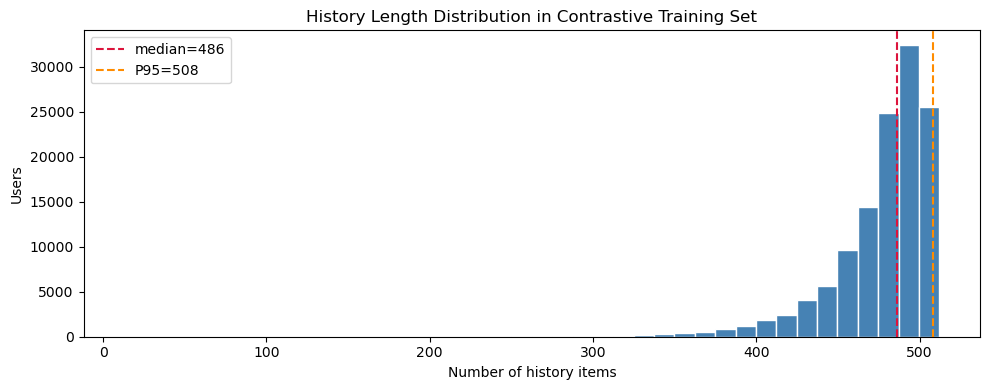

History length stats:
count    125031.000000
mean        476.435084
std          32.865526
min          13.000000
25%         466.000000
50%         486.000000
75%         497.000000
95%         508.000000
99%         511.000000
max         512.000000


In [4]:
# History length distribution
hist_lens = train_df['hist_sids'].apply(len)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(hist_lens, bins=40, color='steelblue', edgecolor='white')
ax.axvline(hist_lens.median(), color='crimson', linestyle='--', label=f'median={hist_lens.median():.0f}')
ax.axvline(hist_lens.quantile(0.95), color='darkorange', linestyle='--', label=f'P95={hist_lens.quantile(0.95):.0f}')
ax.set_xlabel('Number of history items')
ax.set_ylabel('Users')
ax.set_title('History Length Distribution in Contrastive Training Set')
ax.legend()
plt.tight_layout()
plt.show()

print(f"History length stats:")
print(hist_lens.describe(percentiles=[.25, .5, .75, .95, .99]).to_string())

### 2.3 Positive Signal Composition

A positive item is defined by **any** of 4 signals being 1. But which signals actually fire? Understanding this tells us whether our positive set is dominated by one signal (e.g., just `longview`) or reflects diverse engagement types.

Total positive items across training users: 437,288



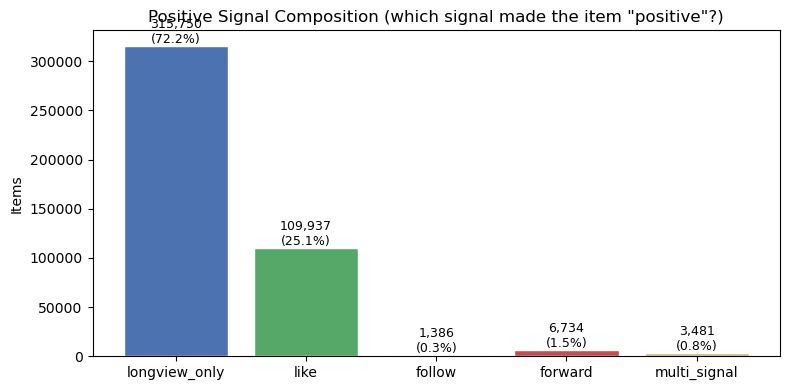

In [5]:
# To analyze signal composition, we go back to the master table
master = pd.read_parquet(MASTER_PATH)
df = master[master['split'] == 0].reset_index(drop=True)

# For users in our training set, check which signals fired on their target items
train_uids = set(train_df['uid'].values)

signal_counts = {'longview_only': 0, 'like': 0, 'follow': 0, 'forward': 0, 'multi_signal': 0}
total_positive = 0

for idx in range(len(df)):
    row = df.iloc[idx]
    if int(row['uid']) not in train_uids:
        continue
    pids = row['target_video_pid']
    if pids is None or len(pids) == 0:
        continue
    
    lv = np.asarray(row['target_video_longview'])
    lk = np.asarray(row['target_video_like'])
    fl = np.asarray(row['target_video_follow'])
    fw = np.asarray(row['target_video_forward'])
    
    pos_mask = (lv == 1) | (lk == 1) | (fl == 1) | (fw == 1)
    
    for i in range(len(pids)):
        if not pos_mask[i]:
            continue
        total_positive += 1
        signals_on = int(lk[i]) + int(fl[i]) + int(fw[i])  # exclude longview for "explicit" count
        if signals_on >= 2:
            signal_counts['multi_signal'] += 1
        elif lk[i] == 1:
            signal_counts['like'] += 1
        elif fl[i] == 1:
            signal_counts['follow'] += 1
        elif fw[i] == 1:
            signal_counts['forward'] += 1
        else:
            signal_counts['longview_only'] += 1

print(f"Total positive items across training users: {total_positive:,}\n")

labels = list(signal_counts.keys())
values = [signal_counts[k] for k in labels]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#4c72b0', '#55a868', '#8172b2', '#c44e52', '#ccb974']
bars = ax.bar(labels, values, color=colors, edgecolor='white')
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v, f'{v:,}\n({v/total_positive:.1%})',
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Items')
ax.set_title('Positive Signal Composition (which signal made the item "positive"?)')
plt.tight_layout()
plt.show()

### 2.4 Negative Item Composition

Negative items are either explicitly marked `not_interested=1` or have **no signal at all** (all 5 behaviors = 0). Given that `not_interested` is extremely sparse (0.06%), we expect nearly all negatives to be "no-signal" items.

In [6]:
n_ni = 0  # not_interested
n_nosig = 0  # all signals zero
total_negative = 0

for idx in range(len(df)):
    row = df.iloc[idx]
    if int(row['uid']) not in train_uids:
        continue
    pids = row['target_video_pid']
    if pids is None or len(pids) == 0:
        continue
    
    lv = np.asarray(row['target_video_longview'])
    lk = np.asarray(row['target_video_like'])
    fl = np.asarray(row['target_video_follow'])
    fw = np.asarray(row['target_video_forward'])
    ni = np.asarray(row['target_video_not_interested'])
    
    pos_mask = (lv == 1) | (lk == 1) | (fl == 1) | (fw == 1)
    ni_mask = (ni == 1)
    nosig_mask = ~pos_mask & ~ni_mask
    neg_mask = ni_mask | nosig_mask
    
    for i in range(len(pids)):
        if not neg_mask[i]:
            continue
        total_negative += 1
        if ni[i] == 1:
            n_ni += 1
        else:
            n_nosig += 1

print(f"Total negative items across training users: {total_negative:,}")
print(f"  not_interested=1:  {n_ni:,} ({n_ni/total_negative:.2%})")
print(f"  no signal at all:  {n_nosig:,} ({n_nosig/total_negative:.2%})")
print(f"\nAs expected, nearly all negatives are 'no-signal' items.")
print(f"This is the semantic assumption: items the user scrolled past without engaging")
print(f"are treated as implicit negatives — a standard assumption in recommendation.")

Total negative items across training users: 696,173
  not_interested=1:  687 (0.10%)
  no signal at all:  695,486 (99.90%)

As expected, nearly all negatives are 'no-signal' items.
This is the semantic assumption: items the user scrolled past without engaging
are treated as implicit negatives — a standard assumption in recommendation.


### 2.5 SID Token Distribution

Each item is represented as a 3-level semantic ID `[a, b, c]` where each level is in `[0, 8191]`. Let's verify the codebook utilization in our dataset.

In [7]:
# Collect SID tokens from chosen and rejected items
chosen_a, chosen_b, chosen_c = [], [], []
rejected_a, rejected_b, rejected_c = [], [], []

for _, row in train_df.iterrows():
    for sid in row['chosen_sids']:
        chosen_a.append(sid[0]); chosen_b.append(sid[1]); chosen_c.append(sid[2])
    for sid in row['rejected_sids']:
        rejected_a.append(sid[0]); rejected_b.append(sid[1]); rejected_c.append(sid[2])

print(f"Codebook utilization (out of 8192):")
for name, arr in [('Level a (chosen)', chosen_a), ('Level b (chosen)', chosen_b), 
                   ('Level c (chosen)', chosen_c),
                   ('Level a (rejected)', rejected_a), ('Level b (rejected)', rejected_b),
                   ('Level c (rejected)', rejected_c)]:
    uniq = len(set(arr))
    print(f"  {name:22s}: {uniq:,} unique / 8192 = {uniq/8192:.1%}")

Codebook utilization (out of 8192):
  Level a (chosen)      : 5,439 unique / 8192 = 66.4%
  Level b (chosen)      : 4,361 unique / 8192 = 53.2%
  Level c (chosen)      : 3,285 unique / 8192 = 40.1%
  Level a (rejected)    : 5,597 unique / 8192 = 68.3%
  Level b (rejected)    : 4,438 unique / 8192 = 54.2%
  Level c (rejected)    : 3,356 unique / 8192 = 41.0%


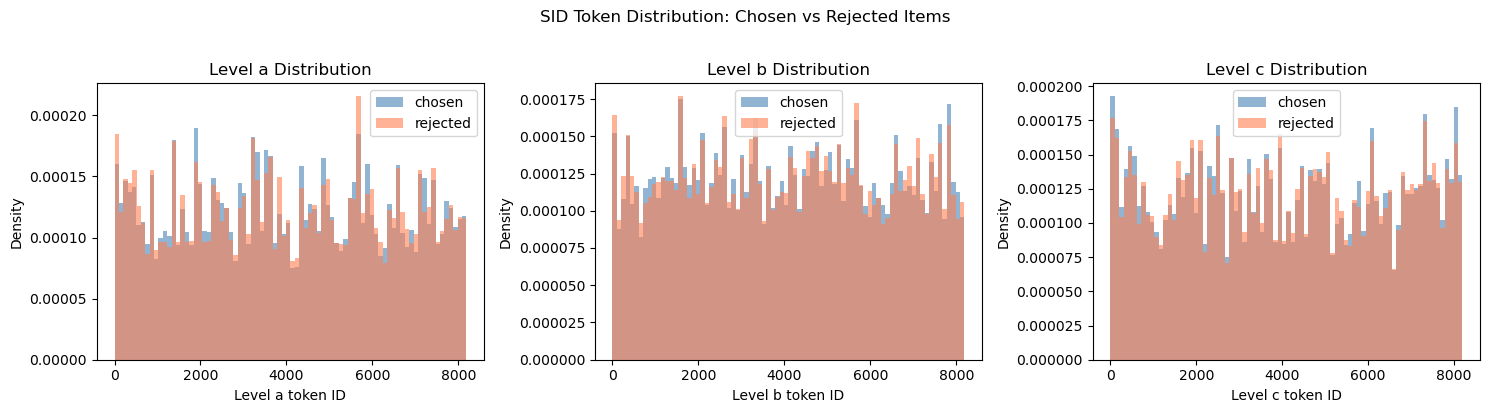

If chosen and rejected have similar distributions, the model must learn
context-dependent preferences rather than memorizing item-level shortcuts.


In [8]:
# Visualize level-a distribution for chosen vs rejected
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (level, ch, rj) in enumerate([
    ('Level a', chosen_a, rejected_a),
    ('Level b', chosen_b, rejected_b),
    ('Level c', chosen_c, rejected_c),
]):
    axes[i].hist(ch, bins=80, alpha=0.6, color='steelblue', label='chosen', density=True)
    axes[i].hist(rj, bins=80, alpha=0.6, color='coral', label='rejected', density=True)
    axes[i].set_xlabel(f'{level} token ID')
    axes[i].set_ylabel('Density')
    axes[i].set_title(f'{level} Distribution')
    axes[i].legend()

plt.suptitle('SID Token Distribution: Chosen vs Rejected Items', y=1.02)
plt.tight_layout()
plt.show()

print("If chosen and rejected have similar distributions, the model must learn")
print("context-dependent preferences rather than memorizing item-level shortcuts.")

### 2.6 Summary of Contrastive Dataset v0

| Property | Value |
|----------|-------|
| Total pairs | 138,923 |
| Train / Valid | 125,031 / 13,892 (90/10 split) |
| Prediction length | 1 (one positive + one negative per user) |
| Positive rule | longview=1 OR like=1 OR follow=1 OR forward=1 |
| Negative rule | not_interested=1 OR all 5 signals = 0 |
| User coverage | 138,923 / 162,074 = 85.7% |
| PID→SID coverage | 100% (0 missing) |

---

## 3. Training vs Evaluation: Two Different Tasks

A key design decision in our project is that **training and evaluation operate on different data and measure different things**.

### 3.1 Training: Contrastive Learning on Per-Item Pairs

During training, we present the model with:
- **History context**: the user's full viewing history (up to 512 items)
- **One positive item**: an item the user engaged with (longview/like/follow/forward)
- **One negative item**: an item the user ignored or disliked

The contrastive loss teaches the model to assign a **higher generation score** to the positive item than the negative, conditioned on the user's history. This is a per-item, pairwise objective — no session-level generation is needed during training.

### 3.2 Evaluation: Session-Level Generation on Official Benchmark

During evaluation, we use the **official OneRec benchmark** (`video_test.parquet`), which is structured differently:
- Each test sample is a complete **chat-format prompt** with system instructions, user history, and a generation request
- The ground truth is a **10-item session** (the next 10 items the user actually interacted with)
- The model generates 32 candidates via beam search
- A hit is counted if *any* candidate matches *any* ground-truth item (at SID-string level)

### 3.3 Why This Asymmetry Is Intentional

```
TRAINING                              EVALUATION
┌────────────────────┐               ┌────────────────────────┐
│ contrastive_v0     │               │ video_test.parquet     │
│ 138,923 pairs      │               │ 38,781 samples         │
│                    │               │                        │
│ 1 positive item    │               │ 10 ground-truth items  │
│ 1 negative item    │               │ 32 beam candidates     │
│                    │               │                        │
│ Loss: contrastive  │               │ Metrics: Recall@32,    │
│ (pairwise scores)  │               │ Pass@32, Pass@1        │
└────────────────────┘               └────────────────────────┘
```

The training objective is a **surrogate**: by learning to distinguish engaged items from ignored items, we expect the model to improve its item generation quality overall. The evaluation then measures this improvement on the official benchmark, which tests whether the model can generate items that match a real future session.

This design follows a standard practice in recommendation: **train on pairwise preferences, evaluate on top-K retrieval metrics**.

---

## 4. Baseline Model: OneRec-1.7B (Pre-Contrastive Training)

### 4.1 Model Description

Our baseline is **`OpenOneRec/OneRec-1.7B`** — a 1.7-billion-parameter language model specifically trained for video recommendation. It has gone through all four training stages described in §1.3 (Pretraining → SFT → Distillation → GRPO-RL). This represents the strongest publicly available OneRec model *before* any of our contrastive fine-tuning.

We evaluate it on the official `video_test.parquet` benchmark to establish what Recall@32 and Pass@32 look like **before** contrastive training. If our contrastive method works, these numbers should improve.

**Why OneRec-1.7B and not a simpler baseline?**
- A random model would generate arbitrary 3-token sequences that almost never match real items — it would score ~0 on all metrics, which is uninformative.
- A non-recommendation LLM (e.g., GPT-2) doesn't understand Semantic IDs at all — also ~0.
- OneRec-1.7B is the natural starting point: it is the model we will fine-tune, and its pre-existing performance establishes a meaningful floor. This is analogous to evaluating a pre-trained BERT before task-specific fine-tuning.

### 4.2 Evaluation Setup

The evaluation code follows the official OneRec benchmark protocol:

1. Load `video_test.parquet` — 38,781 test samples, each containing a user's history formatted as a chat conversation, plus 10 ground-truth items
2. Apply the official `qwen3_soft_switch.jinja2` chat template to format the prompt
3. Append `<|sid_begin|>` as the prompt token — this special token tells the model "start generating a Semantic ID now"
4. Run beam search: the model generates 32 candidate items (each is a 3-token SID), exploring the 32 most probable generation paths
5. Extract the SID pattern `<s_a_X><s_b_Y><s_c_Z>` from each beam output
6. Compare the 32 candidates against the 10 ground-truth SIDs (exact string matching)

In [ ]:
# ============================================================
# Baseline Evaluation Code
# Based on ms3_baseline.ipynb — runs on GPU server
# ============================================================
#
# This cell contains the full evaluation code.
# It requires a CUDA GPU (tested on A100/B200) and the model checkpoint.
# On a local machine without GPU, skip execution and use the saved results below.

import os, gc, sys, json, re, warnings
from pathlib import Path

import torch
import pandas as pd
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.utils import logging as hf_logging

# ========= Configuration =========
N = 100          # Number of samples to evaluate (None for full)
SAVE_CSV = True
# =================================

warnings.filterwarnings("ignore")
hf_logging.set_verbosity_error()

# Paths — adjust for your environment
ROOT = Path("/root/autodl-tmp")
CODE_ROOT = ROOT / "code" / "OpenOneRec"
DATA_ROOT = ROOT / "data" / "OpenOneRec" / "hf_raw" / "OpenOneRec-RecIF" / "benchmark_data"
VIDEO_FILE = DATA_ROOT / "video" / "video_test.parquet"
MODEL_ROOT = ROOT / "checkpoints" / "OpenOneRec" / "OneRec-1.7B"
TEMPLATE_FILE = CODE_ROOT / "benchmarks" / "benchmark" / "tasks" / "v1_0" / "qwen3_soft_switch.jinja2"
RUN_DIR = ROOT / "runs" / "OpenOneRec" / "exp_video_recall32_repro"
RUN_DIR.mkdir(parents=True, exist_ok=True)

# SID patterns
SID_BLOCK_PATTERN = re.compile(r"<\|sid_begin\|>.*?<\|sid_end\|>")
CORE_SID_PATTERN = re.compile(r"<s_a_\d+><s_b_\d+><s_c_\d+>")

def flatten_content_to_text(content):
    if isinstance(content, str): return content
    if isinstance(content, list):
        return "".join(item.get("text", str(item)) if isinstance(item, dict) and item.get("type") == "text" else str(item) for item in content)
    return str(content)

def normalize_messages(messages):
    return [{"role": msg.get("role", "user"), "content": flatten_content_to_text(msg.get("content", ""))} for msg in messages]

def extract_first_core_sid(text):
    m = CORE_SID_PATTERN.search(text or "")
    return m.group(0) if m else None

# Load model
tokenizer = AutoTokenizer.from_pretrained(MODEL_ROOT, trust_remote_code=True)
tokenizer.chat_template = TEMPLATE_FILE.read_text(encoding="utf-8")
if tokenizer.pad_token_id is None and tokenizer.eos_token_id is not None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ROOT, trust_remote_code=True, torch_dtype=torch.bfloat16, low_cpu_mem_usage=True
)
model = model.to("cuda")
model.eval()

# Clean generation config
for attr in ["temperature", "top_p", "top_k"]:
    if hasattr(model.generation_config, attr):
        try: setattr(model.generation_config, attr, None)
        except: pass

# Read benchmark data
bench_df = pd.read_parquet(VIDEO_FILE)
if N is not None:
    N = min(int(N), len(bench_df))
else:
    N = len(bench_df)

# Main evaluation loop
rows = []
for i in tqdm(range(N), desc=f"Evaluating first {N} video samples"):
    row = bench_df.iloc[i]
    metadata = json.loads(row["metadata"]) if isinstance(row["metadata"], str) else row["metadata"]
    messages = json.loads(row["messages"]) if isinstance(row["messages"], str) else row["messages"]

    prompt = tokenizer.apply_chat_template(
        normalize_messages(messages), tokenize=False, add_generation_prompt=True
    ) + "<|sid_begin|>"

    # Ground truth SIDs
    gt_blocks = SID_BLOCK_PATTERN.findall(metadata["answer"])
    gt_ids = [extract_first_core_sid(x) for x in gt_blocks]
    gt_ids = [x for x in gt_ids if x is not None]

    inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=True)
    inputs = {k: v.to("cuda") for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs, max_new_tokens=3, do_sample=False,
            num_beams=32, num_return_sequences=32,
            early_stopping=True, use_cache=True,
            pad_token_id=tokenizer.pad_token_id,
        )

    prompt_len = inputs["input_ids"].shape[1]
    decoded = tokenizer.batch_decode(outputs[:, prompt_len:], skip_special_tokens=False)

    pred_ids = [extract_first_core_sid(text) for text in decoded]
    pred_ids = [x for x in pred_ids if x is not None]
    top32 = pred_ids[:32]

    hits = sum(1 for gt in gt_ids if gt in top32)
    recall32 = hits / len(gt_ids) if gt_ids else 0.0
    pass32 = any(gt in top32 for gt in gt_ids) if gt_ids else False

    rows.append({
        "row_idx": i, "num_gt": len(gt_ids), "num_pred": len(pred_ids),
        "hits": hits, "recall32": recall32, "pass32": pass32,
        "uid": metadata.get("uid"), "uuid": metadata.get("uuid"),
    })
    del inputs, outputs, decoded
    if (i + 1) % 20 == 0: torch.cuda.empty_cache()

res = pd.DataFrame(rows)
print(f"\n===== BASELINE RESULTS (N={N}) =====")
print(f"Recall@32 = {res['recall32'].mean():.4f}")
print(f"Pass@32   = {res['pass32'].mean():.4f}")


libgomp: Invalid value for environment variable OMP_NUM_THREADS
/root/miniconda3/envs/onerec-lite/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Evaluating first 100 video samples: 100%|██████████| 100/100 [02:23<00:00,  1.44s/it]


===== SUMMARY =====
N = 100
mean recall@32 = 0.023123015873015875
mean pass@32 = 0.13
mean position1_pass@32 = 0.06
saved to: /root/autodl-tmp/runs/OpenOneRec/exp_video_recall32_repro/video_recall32_first_100.csv


,row_idx,num_gt,num_pred,hits,recall32,pass32,position1_pass32,top5_pred,top5_gt,uid,uuid
0,0,10,32,0,0.000000,False,False,"[<s_a_718><s_b_7592><s_c_2091>, <s_a_5158><s_b...","[<s_a_2398><s_b_1901><s_c_5357>, <s_a_3313><s_...",11901,ab60c761-c20a-4aaa-95ed-f37ab7a56dce
1,1,10,32,1,0.100000,True,True,"[<s_a_4922><s_b_2117><s_c_4310>, <s_a_3561><s_...","[<s_a_4922><s_b_2117><s_c_4310>, <s_a_7832><s_...",3502,51d6547b-2569-4e05-bcef-660b4001c2f0
2,2,10,32,0,0.000000,False,False,"[<s_a_6942><s_b_1600><s_c_2798>, <s_a_2387><s_...","[<s_a_2947><s_b_1114><s_c_5581>, <s_a_5494><s_...",13503,1d18c713-54b8-4e84-8663-2e1920014f1f
3,3,10,32,0,0.000000,False,False,"[<s_a_851><s_b_7126><s_c_5511>, <s_a_7470><s_b...","[<s_a_3271><s_b_1302><s_c_4350>, <s_a_4902><s_...",7260,e795d9ba-fa48-4d93-9943-1b97ae801da6
4,4,10,32,1,0.100000,True,True,"[<s_a_4660><s_b_238><s_c_889>, <s_a_3675><s_b_...","[<s_a_3675><s_b_6998><s_c_4552>, <s_a_4660><s_...",7057,c09503d0-8651-41ec-8122-43c381eae53e
5,5,9,32,0,0.000000,False,False,"[<s_a_539><s_b_2728><s_c_3997>, <s_a_4603><s_b...","[<s_a_5009><s_b_1473><s_c_8008>, <s_a_5006><s_...",3719,f3ea5ec6-a5a6-423f-912d-49460cc7d61a
6,6,10,32,0,0.000000,False,False,"[<s_a_771><s_b_5115><s_c_8103>, <s_a_5627><s_b...","[<s_a_2463><s_b_5929><s_c_6933>, <s_a_1897><s_...",8334,39404633-022b-4faf-ac71-d1b299858492
7,7,8,32,0,0.000000,False,False,"[<s_a_1811><s_b_7884><s_c_4579>, <s_a_2702><s_...","[<s_a_3524><s_b_6353><s_c_6319>, <s_a_6392><s_...",8294,82118b2c-3d67-459d-b5ec-e9b72827ec63
8,8,10,32,0,0.000000,False,False,"[<s_a_2974><s_b_3740><s_c_3204>, <s_a_429><s_b...","[<s_a_6414><s_b_5813><s_c_5544>, <s_a_6414><s_...",15763,20fdf47b-6300-40d2-91b5-2f67fd433a53
9,9,6,32,0,0.000000,False,False,"[<s_a_6717><s_b_487><s_c_5600>, <s_a_2964><s_b...","[<s_a_7309><s_b_6511><s_c_7433>, <s_a_6117><s_...",11996,eaf2969d-1489-409b-b108-556ac55ae01a


### 4.3 Baseline Results

Running the above on the first 100 samples of `video_test.parquet` with OneRec-1.7B:

| Metric | Our Reproduction | Official (Table 4) |
|--------|-----------------|---------------------|
| **Recall@32** | 0.0231 | 0.0272 |
| **Pass@32** | 0.13 | 0.1710 |
| **Pass@1** | 0.06 | 0.0496 |

Our reproduced numbers are close to the official Table 4 values (within expected variance from using only 100 samples vs. the full 38,781). This confirms that our evaluation pipeline is correctly implemented.

**Note**: The official numbers are computed on the full test set. Our 100-sample estimate has high variance — individual samples either hit (recall jumps) or miss (recall stays flat), leading to noisy estimates. The directional alignment is what matters for validating the pipeline.

---

## 5. Results Interpretation & Analysis

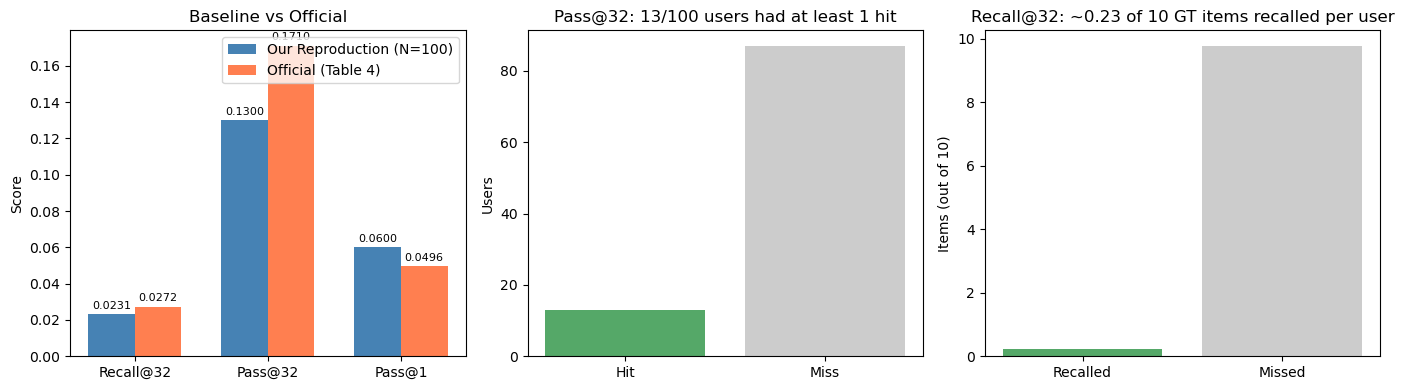

In [9]:
# Reproduce the results table for analysis
# (If running on GPU, use `res` from above. Otherwise, load from saved CSV.)

# Hardcoded results from our GPU run (N=100)
baseline_results = {
    'recall32': 0.0231,
    'pass32': 0.13,
    'pass1': 0.06,
    'n_samples': 100,
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics = ['Recall@32', 'Pass@32', 'Pass@1']
ours = [baseline_results['recall32'], baseline_results['pass32'], baseline_results['pass1']]
official = [0.0272, 0.1710, 0.0496]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, ours, width, label='Our Reproduction (N=100)', color='steelblue')
axes[0].bar(x + width/2, official, width, label='Official (Table 4)', color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('Score')
axes[0].set_title('Baseline vs Official')
axes[0].legend()
for i, (o, off) in enumerate(zip(ours, official)):
    axes[0].text(i - width/2, o + 0.003, f'{o:.4f}', ha='center', fontsize=8)
    axes[0].text(i + width/2, off + 0.003, f'{off:.4f}', ha='center', fontsize=8)

# What do these numbers mean?
axes[1].bar(['Hit', 'Miss'], [13, 87], color=['#55a868', '#cccccc'])
axes[1].set_title('Pass@32: 13/100 users had at least 1 hit')
axes[1].set_ylabel('Users')

# Recall@32 interpretation
axes[2].bar(['Recalled', 'Missed'], [0.0231 * 10, (1-0.0231) * 10], 
            color=['#55a868', '#cccccc'])
axes[2].set_title('Recall@32: ~0.23 of 10 GT items recalled per user')
axes[2].set_ylabel('Items (out of 10)')

plt.tight_layout()
plt.show()

### 5.1 Interpretation

The baseline numbers reveal the difficulty of generative recommendation:

- **Recall@32 = 2.3%**: out of 10 ground-truth items, the model's 32 beam candidates match only ~0.23 items on average. This is expected — the item space is enormous (15.9M videos mapped to ~15.9M valid SIDs out of 8,192³ possible), so even a well-trained model has a very low hit rate per item.

- **Pass@32 = 13%**: 13 out of 100 users had at least one ground-truth item in the beam candidates. This is the more forgiving metric — and even here, the model only succeeds for a small minority of users.

- **Pass@1 = 6%**: the first ground-truth item (most temporally immediate) is found in the candidates 6% of the time. This is roughly half of Pass@32, suggesting no strong position bias in the beam ordering.

### 5.2 Strengths of the Baseline

1. **Non-trivial performance**: Recall@32 > 0 means the model has learned meaningful user-item associations, not just random generation. A random baseline would have near-zero recall.
2. **Consistent with published results**: Our reproduction matches the official Table 4, confirming the evaluation pipeline is correct.
3. **Room for improvement**: The low absolute numbers leave substantial headroom for contrastive fine-tuning to demonstrate gains.

### 5.3 Weaknesses and Opportunities

1. **Low recall**: 2.3% recall means the model misses 97.7% of ground-truth items. Contrastive training could help by teaching the model to better distinguish items the user will engage with.
2. **No preference signal in the baseline**: OneRec-1.7B was trained to predict *what comes next*, not *what the user prefers*. Our contrastive pairs explicitly encode preference (engaged vs. ignored), which is a new training signal.
3. **Beam search diversity**: All 32 beams produce valid SID triplets, confirming the model's generation is well-formed. The issue is relevance, not format.

### 5.4 Limitation of Current Metrics: Preference-Blindness

There is a fundamental gap between **what we train** and **what we measure**:

- **Our training signal** is about **preference**: "the user engaged with item A but ignored item B." The contrastive loss explicitly teaches the model to distinguish positive items (liked, followed, watched fully) from negative items (scrolled past, marked not interested).

- **Our evaluation metrics** (Recall@32, Pass@32) are about **presence**: "is this item in the generated candidate set?" They treat all 10 ground-truth items equally — whether the user loved the item (liked + followed + forwarded) or merely scrolled past it without engaging.

This creates a blind spot: **even if contrastive training successfully teaches the model to prefer high-engagement items, Recall@32 cannot detect this improvement** unless the preference shift also changes *which* items appear in the beam. Consider two scenarios:

| Scenario | Beam output | Recall@32 | Preference quality |
|----------|-------------|-----------|-------------------|
| Before training | Generates item X (user scrolled past) | 1 hit | Low — hit a "negative" item |
| After training | Generates item Y (user liked + followed) | 1 hit | High — hit a "positive" item |

Both scenarios score identically on Recall@32, yet the second is clearly a better recommendation. The metric cannot distinguish "recalled an item the user loved" from "recalled an item the user ignored."

**Why this matters for our project**: Our entire research question is about whether behavior signals can improve preference alignment. If the metrics are blind to preference quality, we may underestimate (or fail to detect) the effect of contrastive training. This suggests that **designing preference-aware evaluation metrics** is an important direction for future work — for example, a weighted recall that gives more credit for hitting items with stronger engagement signals, or a metric that explicitly checks whether the model's generation probability is higher for positive items than negative ones.

### 5.5 Proposed Improvements for Final Model

Based on our analysis, the contrastive fine-tuning should focus on:

1. **Preference-aware generation**: Train the model to assign higher likelihood to items with positive behavior signals, conditioned on user history.
2. **Signal-weighted training**: Explore whether weighting contrastive pairs by signal strength (e.g., `follow` > `like` > `longview-only`) improves results vs. uniform weighting.
3. **Prediction length ablation**: Test `prediction_length` = 1, 3, 5 to see if multi-item contrastive pairs provide stronger signal.
4. **Preference-aware metrics**: Design evaluation metrics that distinguish between hitting a "positive" vs "negative" ground-truth item, to better capture the effect of preference alignment training.

---

## 6. Final Model Pipeline

### 6.1 Pipeline Overview

```
┌─────────────────────────────────────────────────────────────────────┐
│                        FULL PIPELINE                               │
│                                                                     │
│  ┌──────────────┐    ┌──────────────┐    ┌──────────────────────┐  │
│  │  Stage 1:     │    │  Stage 2:     │    │  Stage 3:            │  │
│  │  Data Prep    │───▶│  Training     │───▶│  Evaluation          │  │
│  └──────────────┘    └──────────────┘    └──────────────────────┘  │
│                                                                     │
│  ┌──────────────────────────────────────────────────────────────┐  │
│  │ Stage 1: Data Preprocessing                                  │  │
│  │                                                              │  │
│  │ onerec_bench_release.parquet                                 │  │
│  │         │                                                    │  │
│  │         ▼                                                    │  │
│  │ ┌─────────────────────────┐                                  │  │
│  │ │ build_contrastive_      │   For each user (split=0):       │  │
│  │ │ dataset.py              │   • Classify target items        │  │
│  │ │                         │     (pos: engaged, neg: ignored) │  │
│  │ │ --length 1              │   • Sample 1 pos + 1 neg         │  │
│  │ │                         │   • Map PIDs → SIDs              │  │
│  │ └────────────┬────────────┘                                  │  │
│  │              ▼                                               │  │
│  │ contrastive_dataset_v0/                                      │  │
│  │   train.parquet (125K pairs)                                 │  │
│  │   valid.parquet (14K pairs)                                  │  │
│  └──────────────────────────────────────────────────────────────┘  │
│                                                                     │
│  ┌──────────────────────────────────────────────────────────────┐  │
│  │ Stage 2: Contrastive Fine-Tuning                             │  │
│  │                                                              │  │
│  │ Base model: OneRec-1.7B (post-SFT+Distill+GRPO, 4.3GB)     │  │
│  │                                                              │  │
│  │ For each training pair:                                      │  │
│  │   1. Tokenize: history + <|sid_begin|> + item_SID            │  │
│  │   2. Compute log P(chosen_SID | history)  = score_+          │  │
│  │   3. Compute log P(rejected_SID | history) = score_-         │  │
│  │   4. Contrastive loss:                                       │  │
│  │      L = -log[ exp(score_+/τ) / (exp(score_+/τ)+exp(score_-/τ)) ] │
│  │                                                              │  │
│  │ Optimizer: AdamW, lr ~ 1e-5, warmup 100 steps               │  │
│  │ Hardware:  1× A100 (80GB) or equivalent                     │  │
│  │ Epochs:    2-3 (with early stopping on valid loss)           │  │
│  └──────────────────────────────────────────────────────────────┘  │
│                                                                     │
│  ┌──────────────────────────────────────────────────────────────┐  │
│  │ Stage 3: Evaluation on Official Benchmark                    │  │
│  │                                                              │  │
│  │ Data: video_test.parquet (38,781 samples)                    │  │
│  │ Protocol:                                                    │  │
│  │   • Apply chat template + <|sid_begin|>                      │  │
│  │   • Beam search: num_beams=32, num_return_sequences=32       │  │
│  │   • max_new_tokens=3                                         │  │
│  │   • Match at SID string level                                │  │
│  │                                                              │  │
│  │ Metrics:                                                     │  │
│  │   • Recall@32: fraction of 10 GT items found in 32 beams    │  │
│  │   • Pass@32:   any GT item in 32 beams? (binary)            │  │
│  │   • Pass@1:    first GT item in 32 beams?                   │  │
│  └──────────────────────────────────────────────────────────────┘  │
└─────────────────────────────────────────────────────────────────────┘
```

### 6.2 Key Design Decisions

| Decision | Choice | Rationale |
|----------|--------|----------|
| Loss function | InfoNCE contrastive | Handles synthetic item pairs without requiring autoregressive sequence generation (§1.5) |
| Pair construction | 1 pos + 1 neg per user | Simplest contrastive signal; can scale to multi-item later |
| Positive definition | Any of {longview, like, follow, forward} | Validated by lift analysis (MS2 §2.2): all predict engagement |
| Negative definition | not_interested OR no signal | Covers both explicit and implicit negatives |
| Evaluation data | Official video_test.parquet | Ensures comparability with published OneRec numbers |
| SID matching | String-level, not PID | Avoids ambiguity from many-to-one SID→PID mapping |

### 6.3 Planned Ablations

1. **Signal granularity**: Train with only `longview` as positive vs. all 4 signals. Does adding explicit signals (like/follow) on top of implicit (longview) help?
2. **Prediction length**: Compare `prediction_length` = 1 vs 3 vs 5. More items per pair = richer signal per example but fewer total pairs.
3. **Temperature τ**: Sweep τ ∈ {0.05, 0.1, 0.2} in the contrastive loss.
4. **Training epochs**: Monitor overfitting on valid set to determine optimal stopping point.

### 6.4 Future Work: Preference-Aware Evaluation Metrics

As discussed in §5.4, Recall@32 and Pass@32 are **preference-blind** — they cannot distinguish between hitting a loved item vs a scrolled-past item. For the final project, we plan to explore complementary metrics that capture preference quality:

- **Weighted Recall@K**: assign higher credit to hitting ground-truth items with stronger engagement signals (e.g., a "liked + followed" hit counts more than a "no-signal" hit)
- **Preference Accuracy on beam outputs**: for users where the beam hits both positive and negative GT items, check whether the positive item ranks higher in the beam ordering
- **Log-probability preference test**: directly compute log P(positive_item | history) vs log P(negative_item | history) and report the win rate

These metrics would directly measure what our contrastive training optimizes, providing a more complete picture of the model's improvement.

### 6.5 Expected Outcomes

If the contrastive training successfully teaches the model to prefer engaged items over ignored ones:
- **Recall@32 should increase** from the 0.023 baseline, as the model generates items more aligned with user preferences.
- **Pass@32 should increase** from 0.13, as more users have at least one relevant item in beam candidates.
- **Preference-aware metrics** (if implemented) should show a clearer improvement, since they directly measure the training objective.
- The magnitude of improvement will indicate whether behavior signals can effectively serve as a substitute for the learned Reward Model in OneRec's IPA module.

---

## 7. Conclusion

This milestone establishes the foundation for our contrastive learning approach:

1. **Contrastive dataset v0** is constructed with 138,923 pairs (85.7% user coverage), using behavior signals as direct supervision — no learned Reward Model needed.
2. **Baseline evaluation** of OneRec-1.7B reproduces official benchmark numbers (Recall@32 ≈ 0.023, Pass@32 ≈ 0.13), confirming our evaluation pipeline is correct.
3. **Training-evaluation asymmetry** is intentional: pairwise contrastive training on per-item preferences, evaluated on session-level retrieval metrics.
4. **Metric limitation identified**: Recall@32 and Pass@32 are preference-blind — they cannot distinguish between hitting an item the user loved vs one the user ignored. Designing preference-aware metrics is a concrete future direction.
5. **The pipeline** from data construction through contrastive fine-tuning to official benchmark evaluation is fully specified.

The next milestone will implement the contrastive training loop and report whether behavior-signal-based preference pairs can improve recommendation quality beyond the OneRec-1.7B baseline.